# Анализ признаков region_id и region_name

Цель: оценить качество и полезность региональных признаков на уровне полиса (contract-level) для frequency-severity модели.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

In [33]:
DATA_PATH = "dataset/train.csv"
COL_ID = "region_id"
COL_NAME = "region_name"

df = pd.read_csv(DATA_PATH)
df.head()

/tmp/ipykernel_2084960/1042448018.py:5: DtypeWarning: Columns (0: bonus_malus, 1: car_year) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,unique_id,contract_number,premium,premium_wo_term,operation_date,claim_amount,claim_cnt,is_claim,insurer_iin,driver_iin,is_individual_person,is_individual_person_name,is_residence,is_residence_name,region_id,region_name,bonus_malus,age_experience_id,age_experience_name,experience_year,vehicle_type_id,vehicle_type_name,car_age,ownerkato,ownerkato_short,model,mark,car_number,car_year,engine_volume,engine_power,SCORE_1_1,SCORE_1_2,SCORE_1_3,SCORE_1_4,SCORE_1_5,SCORE_1_6,SCORE_1_7,SCORE_1_8,SCORE_1_9,SCORE_1_10,SCORE_2_1,SCORE_2_2,SCORE_2_3,SCORE_3_1,SCORE_3_2,SCORE_3_3,SCORE_3_4,SCORE_3_5,SCORE_3_6,SCORE_3_7,SCORE_3_8,SCORE_3_9,SCORE_3_10,SCORE_4_1,SCORE_4_2,SCORE_4_3,SCORE_4_4,SCORE_4_5,SCORE_4_6,SCORE_4_7,SCORE_4_8,SCORE_4_9,SCORE_4_10,SCORE_4_11,SCORE_4_12,SCORE_4_13,SCORE_4_14,SCORE_4_15,SCORE_4_16,SCORE_4_17,SCORE_4_18,SCORE_4_19,SCORE_4_20,SCORE_4_21,SCORE_4_22,SCORE_4_23,SCORE_4_24,SCORE_4_25,SCORE_4_26,SCORE_4_27,SCORE_4_28,SCORE_4_29,SCORE_4_30,SCORE_5_1,SCORE_5_2,SCORE_5_3,SCORE_5_4,SCORE_5_5,SCORE_5_6,SCORE_5_7,SCORE_5_8,SCORE_5_9,SCORE_5_10,SCORE_5_11,SCORE_5_12,SCORE_6_1,SCORE_6_2,SCORE_6_3,SCORE_7_1,SCORE_7_2,SCORE_7_3,SCORE_8_1,SCORE_8_2,SCORE_8_3,SCORE_9_1,SCORE_9_2,SCORE_9_3,SCORE_9_4,SCORE_9_5,SCORE_9_6,SCORE_9_7,SCORE_9_8,SCORE_9_9,SCORE_9_10,SCORE_9_11,SCORE_9_12,SCORE_9_13,SCORE_9_14,SCORE_9_15,SCORE_9_16,SCORE_9_17,SCORE_9_18,SCORE_9_19,SCORE_9_20,SCORE_9_21,SCORE_9_22,SCORE_9_23,SCORE_9_24,SCORE_10_1,SCORE_10_2,SCORE_10_3,SCORE_10_4,SCORE_10_5,SCORE_10_6,SCORE_11_1,SCORE_11_2,SCORE_11_3,SCORE_11_4,SCORE_11_5,SCORE_11_6,SCORE_11_7,SCORE_11_8,SCORE_11_9,SCORE_11_10,SCORE_11_11,SCORE_11_12,SCORE_11_13,SCORE_11_14,SCORE_12_1,SCORE_12_2,SCORE_12_3,SCORE_12_4,SCORE_12_5,SCORE_12_6,SCORE_12_9_1,SCORE_12_8,SCORE_12_7,SCORE_12_10
0,C97AFBBF-D191-42BB-8429-71F99D7F4B65,30f1c038516aaa697b828a90080f6f8e6d5d262b1dd48b...,11691.0,11691.0,2022-01-03,NaN,NaN,0,e03a6f9affcd3342d3d3faa53a8a3423864e7a7224f048...,e03a6f9affcd3342d3d3faa53a8a3423864e7a7224f048...,1,Физ. лицо,1,Резидент,1,01 Алматинская область,13,5,старше 25 лет/стаж вождения более 2 лет,10,1,Легковые,до 7 лет включ.,1.952201e+09,1952.0,SONATA,HYUNDAI,61a50ba901fe1e632512ae9796d87856f255ef0f243b3e...,2020,2497.0,132.0,7.0,5.0,4.0,1.0,2.0,3.0,7.0,5.0,9.0,43.0,4.0,4.0,12.0,6.0,7.0,11.0,1.0,8.0,11.0,11.0,2.0,2.0,10.0,10.0,11.0,10.0,8.0,1.0,10.0,8.0,1.0,1.0,4.0,6.0,7.0,11.0,6.0,7.0,5.0,11.0,10.0,10.0,4.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,11.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,8.0,10.0,10.0,4.0,10.0,10.0,8.0,6.0,1.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,1.0,6.0,5.0,9.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
1,CBF0BF9E-B247-41EE-A59C-79D56F619034,6eb065f0890396984fd1c6e7b71c3d1643f345906a8c59...,14121.0,14121.0,2022-01-03,NaN,NaN,0,ccbc33ecce804b79c57fd692d9974fba302b27a15bfd27...,6c4851642b845a87e17f96c16bdd99e13da640e783c2f6...,1,Физ. лицо,1,Резидент,20,18 Туркестанская область,13,5,старше 25 лет/стаж вождения более 2 лет,0,1,Легковые,свыше 7 лет,6.116100e+09,6116.0,21703 138 31,LADA,47b6f0d2d4f70ffa0a154e9500ac2b80af5aae48b3c2aa...,2013,1596.0,59.0,9.0,9.0,9.0,2.0,3.0,5.0,10.0,10.0,10.0,67.0,2.0,9.0,25.0,10.0,1.0,11.0,1.0,6.0,10.0,10.0,10.0,10.0,10.0,5.0,7.0,4.0,3.0,1.0,5.0,3.0,1.0,1.0,1.0,1.0,5.0,10.0,4.0,3.0,1.0,1.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,8.0,7.0,8.0,7.0,7.0,6.0,8.0,7.0,8.0,7.0,7.0,6.0,1.0,4.0,6.0,NaN,NaN,NaN,1.0,1.0,1.0,6.0,6.0,5.0,5.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,5.0,5.0,6.0,6.0,6.0,6.0,7.0,6.0,6.0,6.0,1.0,1.0,1.0,1.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
2,9470871E-8BA6-4FAD-B4F9-9457229652E9,369c23be5e6c413661e872e20bc682df54ccc7f2eb0193...,7371.0,4483.0,2022-01-03,NaN,NaN,0,9e1e95a053b9d27a89d2defea5cf6c8cbbcf0b924a40db...,9e1e95a053b9d27a89d2defea5cf6c8cbbcf0b924a40db...,1,Физ. л

In [34]:
# Агрегируем до уровня полиса, чтобы избежать искусственного увеличения выборки
def _mode_or_multi(series: pd.Series) -> str:
    values = series.dropna()
    if values.empty:
        return np.nan
    uniq = values.unique()
    if len(uniq) == 1:
        return uniq[0]
    return "MULTI"

agg_map = {
    COL_ID: _mode_or_multi,
    COL_NAME: _mode_or_multi,
    "premium": "first",
    "premium_wo_term": "first",
    "claim_amount": "first",
    "claim_cnt": "first",
    "is_claim": "first",
}

df_contract = (
    df.groupby("contract_number", as_index=False)
      .agg(agg_map)
)

df_contract.head()

,contract_number,region_id,region_name,premium,premium_wo_term,claim_amount,claim_cnt,is_claim
0,000153ebe13e6fff0f59b2977d403c82ca2a97f3133d96...,13,13 Атырауская область,16195.0,16195.0,NaN,NaN,0
1,0001a1cb0431d08f3ccb0a5ec65349678dad2266de183d...,1,01 Алматинская область,14289.0,14289.0,NaN,NaN,0
2,0001e313d188345c3faa257552bd4287469bf7268229e0...,5,05 Карагандинская область,7249.0,7249.0,NaN,NaN,0
3,0001e54c51ced85c85e97021b85639040db9301adc151e...,1,01 Алматинская область,6483.0,6483.0,NaN,NaN,0
4,0001ecb71a613337bd5264c47e8383d56b5428994b94fd...,3,03 Восточно-Казахстанская область,5949.0,291.0,NaN,NaN,0


In [35]:
# Проверяем консистентность region_id и region_name
id_name_map = (
    df_contract[[COL_ID, COL_NAME]]
    .dropna()
    .astype({COL_ID: str, COL_NAME: str})
)

names_per_id = id_name_map.groupby(COL_ID)[COL_NAME].nunique().sort_values(ascending=False)
ids_per_name = id_name_map.groupby(COL_NAME)[COL_ID].nunique().sort_values(ascending=False)

print("Уникальных названий на один region_id (топ-10):")
display(names_per_id.head(10))
print("Уникальных id на один region_name (топ-10):")
display(ids_per_name.head(10))

multi_share_id = (df_contract[COL_ID] == "MULTI").mean()
multi_share_name = (df_contract[COL_NAME] == "MULTI").mean()
print(f"Доля полисов с MULTI в region_id: {multi_share_id:.4f}")
print(f"Доля полисов с MULTI в region_name: {multi_share_name:.4f}")

Уникальных названий на один region_id (топ-10):


region_id
1     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
Name: region_name, dtype: int64

Уникальных id на один region_name (топ-10):


region_name
01 Алматинская область               1
03 Восточно-Казахстанская область    1
04 Костанайская область              1
05 Карагандинская область            1
06 Северо-Казахстанская область      1
07 Акмолинская область               1
08 Павлодарская область              1
09 Жамбылская область                1
10 Актюбинская область               1
11 Западно-Казахстанская область     1
Name: region_id, dtype: int64

Доля полисов с MULTI в region_id: 0.0141
Доля полисов с MULTI в region_name: 0.0141


Доля пропусков region_id: 0.0000
Доля пропусков region_name: 0.0000
Кардинальность region_id: 23
Кардинальность region_name: 23


,region_id,region_name,cnt
0,1,01 Алматинская область,35564
13,15,15 Алматы,24449
18,20,18 Туркестанская область,21717
17,19,17 Шымкент,19241
14,16,16 Астана,17210
3,5,05 Карагандинская область,12996
7,9,09 Жамбылская область,11031
8,10,10 Актюбинская область,5755
10,12,12 Кызылординская область,5715
12,14,14 Мангистауская область,5110


count       23.000000
mean      7853.695652
std       9603.332724
min         68.000000
25%       1250.000000
50%       3685.000000
75%      12013.500000
90%      21221.800000
95%      24175.800000
max      35564.000000
Name: cnt, dtype: float64

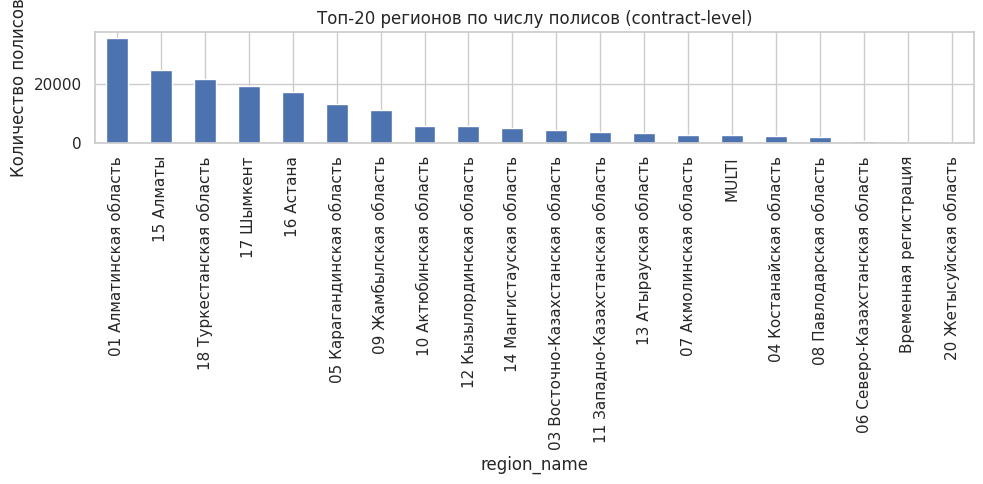

In [36]:
# Дистрибуция, пропуски, кардинальность
missing_rate_id = df_contract[COL_ID].isna().mean()
missing_rate_name = df_contract[COL_NAME].isna().mean()
cardinality_id = df_contract[COL_ID].nunique(dropna=True)
cardinality_name = df_contract[COL_NAME].nunique(dropna=True)

print(f"Доля пропусков region_id: {missing_rate_id:.4f}")
print(f"Доля пропусков region_name: {missing_rate_name:.4f}")
print(f"Кардинальность region_id: {cardinality_id}")
print(f"Кардинальность region_name: {cardinality_name}")

region_counts = (
    df_contract.groupby([COL_ID, COL_NAME])
    .size()
    .reset_index(name="cnt")
    .sort_values("cnt", ascending=False)
)
display(region_counts.head(20))

count_percentiles = region_counts["cnt"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
display(count_percentiles)

plt.figure(figsize=(10, 5))
region_counts.head(20).set_index(COL_NAME)["cnt"].plot(kind="bar")
plt.title("Топ-20 регионов по числу полисов (contract-level)")
plt.xlabel("region_name")
plt.ylabel("Количество полисов")
plt.tight_layout()
plt.show()

In [37]:
# Корреляции с таргетами (категориальный признак кодируем порядково)
cat_codes = df_contract[COL_ID].astype("category").cat.codes

for target in ["is_claim", "claim_amount"]:
    pearson = cat_codes.corr(df_contract[target], method="pearson")
    spearman = cat_codes.corr(df_contract[target], method="spearman")
    print(f"{target}: Pearson={pearson:.6f}, Spearman={spearman:.6f}")

# Дополнительно: средняя частота выплат по регионам
region_claim_rate = (
    df_contract.groupby([COL_ID, COL_NAME])["is_claim"].mean().sort_values(ascending=False)
)
display(region_claim_rate.head(20))

is_claim: Pearson=-0.015367, Spearman=-0.013506
claim_amount: Pearson=-0.002570, Spearman=0.004501


region_id  region_name                      
4          04 Костанайская область              0.038576
16         16 Астана                            0.035038
3          03 Восточно-Казахстанская область    0.026420
5          05 Карагандинская область            0.025546
8          08 Павлодарская область              0.022331
1          01 Алматинская область               0.020779
15         15 Алматы                            0.019960
7          07 Акмолинская область               0.019875
12         12 Кызылординская область            0.018898
11         11 Западно-Казахстанская область     0.016554
10         10 Актюбинская область               0.015639
13         13 Атырауская область                0.014841
23         21 Улытауская область                0.014706
9          09 Жамбылская область                0.014686
20         18 Туркестанская область             0.013860
6          06 Северо-Казахстанская область      0.013554
19         17 Шымкент                      

In [38]:
# Компактная таблица корреляций (чтобы было видно в выводе)
corr_rows = []
cat_codes = df_contract[COL_ID].astype("category").cat.codes

for target in ["is_claim", "claim_amount"]:
    pearson = cat_codes.corr(df_contract[target], method="pearson")
    spearman = cat_codes.corr(df_contract[target], method="spearman")
    corr_rows.append({"target": target, "pearson": pearson, "spearman": spearman})

corr_table = pd.DataFrame(corr_rows)
display(corr_table)


,target,pearson,spearman
0,is_claim,-0.015367,-0.013506
1,claim_amount,-0.002570,0.004501


In [39]:
# WoE/IV для категориального признака
def woe_iv_categorical(data: pd.DataFrame, feature: str, target: str) -> tuple[pd.DataFrame, float]:
    df_tmp = data[[feature, target]].copy()
    df_tmp[feature] = df_tmp[feature].astype(str).fillna("MISSING")

    total_good = (df_tmp[target] == 0).sum()
    total_bad = (df_tmp[target] == 1).sum()

    agg = (
        df_tmp.groupby(feature)[target]
        .agg(["count", "sum"])
        .rename(columns={"sum": "bad"})
    )
    agg["good"] = agg["count"] - agg["bad"]

    # Сглаживание, чтобы избежать деления на ноль
    agg["bad_rate"] = (agg["bad"] + 0.5) / (total_bad + 1.0)
    agg["good_rate"] = (agg["good"] + 0.5) / (total_good + 1.0)
    agg["woe"] = np.log(agg["good_rate"] / agg["bad_rate"])
    agg["iv"] = (agg["good_rate"] - agg["bad_rate"]) * agg["woe"]

    iv_total = agg["iv"].sum()
    return agg.sort_values("iv", ascending=False), iv_total

woe_table, iv_value = woe_iv_categorical(df_contract, COL_ID, "is_claim")
display(woe_table.head(20))
print(f"IV (is_claim): {iv_value:.6f}")

,count,bad,good,bad_rate,good_rate,woe,iv
region_id,,,,,,,
16,17210,603,16607,0.168764,0.093795,-0.587386,0.044036
19,19241,248,18993,0.069491,0.107271,0.434160,0.016403
20,21717,301,21416,0.084312,0.120955,0.360897,0.013225
4,2359,91,2268,0.025587,0.012812,-0.691714,0.008837
14,5110,60,5050,0.016918,0.028524,0.522350,0.006062
5,12996,332,12664,0.092981,0.071526,-0.262331,0.005628
9,11031,162,10869,0.045442,0.061388,0.300789,0.004797
18,300,0,300,0.000140,0.001697,2.496345,0.003888
MULTI,2554,29,2525,0.008249,0.014263,0.547555,0.003293


IV (is_claim): 0.115160


In [40]:
# Климатические зоны - заполните маппинг под ваши region_name
region_list = sorted(df_contract[COL_NAME].dropna().unique())

display(region_list)

climate_map = {name: "UNKNOWN" for name in region_list}
# TODO: заполнить climate_map (например: "steppe", "desert", "mountain", "continental", ...)

claims_pos = df_contract["claim_amount"].where(df_contract["claim_amount"] > 0)

df_contract["region_climate"] = df_contract[COL_NAME].map(climate_map).fillna("MISSING")
df_contract["claim_amount_pos"] = claims_pos

climate_stats = (
    df_contract.groupby("region_climate")
    .agg(
        policies=("contract_number", "count"),
        claim_rate=("is_claim", "mean"),
        claim_amount_pos_mean=("claim_amount_pos", "mean"),
        premium_wo_term_mean=("premium_wo_term", "mean"),
    )
    .sort_values("policies", ascending=False)
)

display(climate_stats)

woe_climate, iv_climate = woe_iv_categorical(df_contract, "region_climate", "is_claim")
display(woe_climate.head(20))
print(f"IV (region_climate): {iv_climate:.6f}")


['01 Алматинская область',
 '03 Восточно-Казахстанская область',
 '04 Костанайская область',
 '05 Карагандинская область',
 '06 Северо-Казахстанская область',
 '07 Акмолинская область',
 '08 Павлодарская область',
 '09 Жамбылская область',
 '10 Актюбинская область',
 '11 Западно-Казахстанская область',
 '12 Кызылординская область',
 '13 Атырауская область',
 '14 Мангистауская область',
 '15 Алматы',
 '16 Астана',
 '17 Шымкент',
 '18 Туркестанская область',
 '19 Абайская область',
 '20 Жетысуйская область',
 '21 Улытауская область',
 'MULTI',
 'Временная регистрация',
 'Временный въезд']

,policies,claim_rate,claim_amount_pos_mean,premium_wo_term_mean
region_climate,,,,
UNKNOWN,180635,0.019791,663414.391631,10645.020566


,count,bad,good,bad_rate,good_rate,woe,iv
region_climate,,,,,,,
UNKNOWN,180635,3575,177060,0.99986,0.999997,0.000137,1.876956e-08


IV (region_climate): 0.000000


In [41]:
# Макрорегионы (север/юг/восток/запад/центр) - по полным названиям
region_list = sorted(df_contract[COL_NAME].dropna().unique())
display(region_list)

macro_map = {
    # Восточный
    "03 Восточно-Казахстанская область": "east",
    "19 Абайская область": "east",
    # Центральный
    "05 Карагандинская область": "central",
    "21 Улытауская область": "central",
    # Западный
    "13 Атырауская область": "west",
    "11 Западно-Казахстанская область": "west",
    "10 Актюбинская область": "west",
    "14 Мангистауская область": "west",
    # Северный
    "07 Акмолинская область": "north",
    "04 Костанайская область": "north",
    "06 Северо-Казахстанская область": "north",
    "08 Павлодарская область": "north",
    "16 Астана": "north",
    # Южный (все остальные области и города по списку)
    "01 Алматинская область": "south",
    "09 Жамбылская область": "south",
    "12 Кызылординская область": "south",
    "15 Алматы": "south",
    "17 Шымкент": "south",
    "18 Туркестанская область": "south",
    "20 Жетысуйская область": "south",
    # Остальные статусы
    "Временная регистрация": "other",
    "Временный въезд": "other",
    "MULTI": "MULTI",
}

claims_pos = df_contract["claim_amount"].where(df_contract["claim_amount"] > 0)

def map_macro(name: str) -> str:
    if name is None or pd.isna(name):
        return "MISSING"
    return macro_map.get(name, "other")

df_contract["region_macro"] = df_contract[COL_NAME].map(map_macro)
df_contract["claim_amount_pos"] = claims_pos

macro_stats = (
    df_contract.groupby("region_macro")
    .agg(
        policies=("contract_number", "count"),
        claim_rate=("is_claim", "mean"),
        claim_amount_pos_mean=("claim_amount_pos", "mean"),
        premium_wo_term_mean=("premium_wo_term", "mean"),
    )
    .sort_values("policies", ascending=False)
)

display(macro_stats)

woe_macro, iv_macro = woe_iv_categorical(df_contract, "region_macro", "is_claim")
display(woe_macro.head(20))
print(f"IV (region_macro): {iv_macro:.6f}")


['01 Алматинская область',
 '03 Восточно-Казахстанская область',
 '04 Костанайская область',
 '05 Карагандинская область',
 '06 Северо-Казахстанская область',
 '07 Акмолинская область',
 '08 Павлодарская область',
 '09 Жамбылская область',
 '10 Актюбинская область',
 '11 Западно-Казахстанская область',
 '12 Кызылординская область',
 '13 Атырауская область',
 '14 Мангистауская область',
 '15 Алматы',
 '16 Астана',
 '17 Шымкент',
 '18 Туркестанская область',
 '19 Абайская область',
 '20 Жетысуйская область',
 '21 Улытауская область',
 'MULTI',
 'Временная регистрация',
 'Временный въезд']

,policies,claim_rate,claim_amount_pos_mean,premium_wo_term_mean
region_macro,,,,
south,117872,0.017358,759712.401310,10374.551064
north,24635,0.032271,547972.423270,13156.223868
west,17717,0.014562,547320.624031,9801.345770
central,13064,0.025490,496865.013514,9629.224434
east,4374,0.025834,490891.407080,12750.523548
MULTI,2554,0.011355,671389.379310,6586.012921
other,419,0.002387,91009.000000,9194.591885


,count,bad,good,bad_rate,good_rate,woe,iv
region_macro,,,,,,,
north,24635,795,23840,0.222455,0.134646,-0.502079,0.044087
south,117872,2046,115826,0.572287,0.654162,0.133713,0.010948
west,17717,258,17459,0.072287,0.098607,0.310494,0.008172
central,13064,333,12731,0.093261,0.071905,-0.260058,0.005554
other,419,1,418,0.000419,0.002364,1.728962,0.003361
MULTI,2554,29,2525,0.008249,0.014263,0.547555,0.003293
east,4374,113,4261,0.031739,0.024068,-0.276676,0.002122


IV (region_macro): 0.077538


In [42]:
# Климатические зоны - маппинг по заданным регионам
region_list = sorted(df_contract[COL_NAME].dropna().unique())

display(region_list)

climate_map = {
    # Холодная северная степь
    "07 Акмолинская область": "cold_steppe",
    "04 Костанайская область": "cold_steppe",
    "06 Северо-Казахстанская область": "cold_steppe",
    "08 Павлодарская область": "cold_steppe",
    # Восток - холодный + горный
    "03 Восточно-Казахстанская область": "mountain_cold",
    "19 Абайская область": "mountain_cold",
    # Центральная сухая континентальная
    "05 Карагандинская область": "dry_continental",
    "21 Улытауская область": "dry_continental",
    # Западная засушливая
    "13 Атырауская область": "arid_hot",
    "11 Западно-Казахстанская область": "arid_hot",
    "10 Актюбинская область": "arid_hot",
    "14 Мангистауская область": "arid_hot",
    # Южная жаркая
    "09 Жамбылская область": "hot_south",
    "12 Кызылординская область": "hot_south",
    "18 Туркестанская область": "hot_south",
    # Юго-восток предгорный
    "01 Алматинская область": "foothill",
    "20 Жетысуйская область": "foothill",
    # Города отдельно
    "15 Алматы": "metro_foothill",
    "16 Астана": "metro_cold_steppe",
    "17 Шымкент": "metro_hot",
    # Остальные статусы
    "Временная регистрация": "other",
    "Временный въезд": "other",
    "MULTI": "MULTI",
}

claims_pos = df_contract["claim_amount"].where(df_contract["claim_amount"] > 0)

def map_climate(name: str) -> str:
    if name is None or pd.isna(name):
        return "MISSING"
    return climate_map.get(name, "other")

df_contract["region_climate"] = df_contract[COL_NAME].map(map_climate)
df_contract["claim_amount_pos"] = claims_pos

climate_stats = (
    df_contract.groupby("region_climate")
    .agg(
        policies=("contract_number", "count"),
        claim_rate=("is_claim", "mean"),
        claim_amount_pos_mean=("claim_amount_pos", "mean"),
        premium_wo_term_mean=("premium_wo_term", "mean"),
    )
    .sort_values("policies", ascending=False)
)

display(climate_stats)

woe_climate, iv_climate = woe_iv_categorical(df_contract, "region_climate", "is_claim")
display(woe_climate.head(20))
print(f"IV (region_climate): {iv_climate:.6f}")


['01 Алматинская область',
 '03 Восточно-Казахстанская область',
 '04 Костанайская область',
 '05 Карагандинская область',
 '06 Северо-Казахстанская область',
 '07 Акмолинская область',
 '08 Павлодарская область',
 '09 Жамбылская область',
 '10 Актюбинская область',
 '11 Западно-Казахстанская область',
 '12 Кызылординская область',
 '13 Атырауская область',
 '14 Мангистауская область',
 '15 Алматы',
 '16 Астана',
 '17 Шымкент',
 '18 Туркестанская область',
 '19 Абайская область',
 '20 Жетысуйская область',
 '21 Улытауская область',
 'MULTI',
 'Временная регистрация',
 'Временный въезд']

,policies,claim_rate,claim_amount_pos_mean,premium_wo_term_mean
region_climate,,,,
hot_south,38463,0.014845,839455.951839,6878.333359
foothill,35719,0.020689,788478.173992,10525.783057
metro_foothill,24449,0.019960,667467.268443,17954.316168
metro_hot,19241,0.012889,671906.560484,7451.391612
arid_hot,17717,0.014562,547320.624031,9801.345770
metro_cold_steppe,17210,0.035038,506151.169154,13968.333934
dry_continental,13064,0.025490,496865.013514,9629.224434
cold_steppe,7425,0.025859,679317.299479,11273.878519
mountain_cold,4374,0.025834,490891.407080,12750.523548


,count,bad,good,bad_rate,good_rate,woe,iv
region_climate,,,,,,,
metro_cold_steppe,17210,603,16607,0.168764,0.093795,-0.587386,0.044036
metro_hot,19241,248,18993,0.069491,0.107271,0.434160,0.016403
hot_south,38463,571,37892,0.159815,0.214008,0.291995,0.015824
arid_hot,17717,258,17459,0.072287,0.098607,0.310494,0.008172
dry_continental,13064,333,12731,0.093261,0.071905,-0.260058,0.005554
cold_steppe,7425,192,7233,0.053831,0.040853,-0.275867,0.003580
other,419,1,418,0.000419,0.002364,1.728962,0.003361
MULTI,2554,29,2525,0.008249,0.014263,0.547555,0.003293
mountain_cold,4374,113,4261,0.031739,0.024068,-0.276676,0.002122


IV (region_climate): 0.102779


Loss ratio overall: 1.233424


region_macro
north      1.344132
central    1.315271
south      1.271086
MULTI      1.157521
east       0.994620
west       0.813178
other      0.023623
dtype: float64

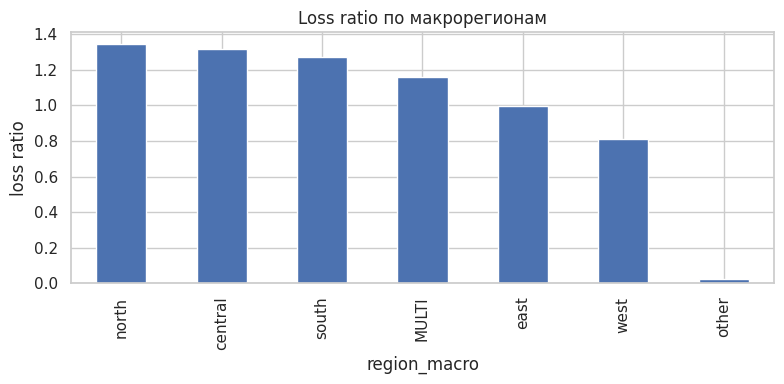

region_climate
hot_south            1.811789
cold_steppe          1.558131
foothill             1.549817
dry_continental      1.315271
metro_cold_steppe    1.269615
metro_hot            1.162239
MULTI                1.157521
mountain_cold        0.994620
arid_hot             0.813178
metro_foothill       0.742027
other                0.023623
dtype: float64

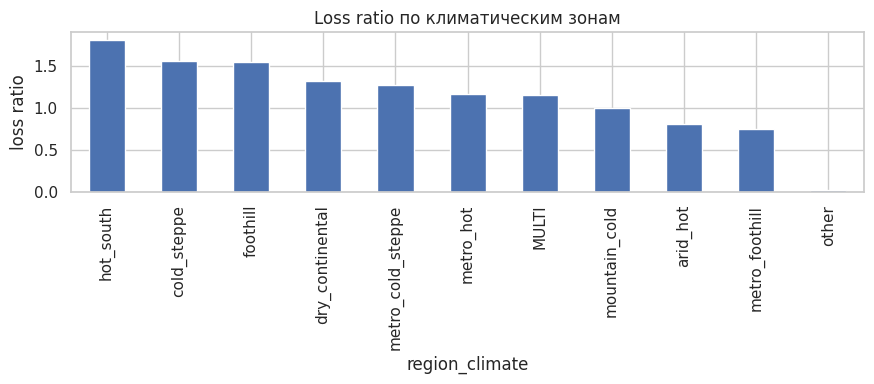

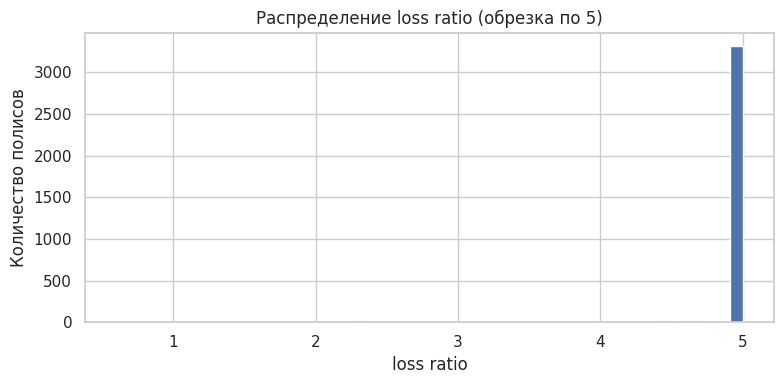

In [43]:
# Loss ratio и графики (contract-level)

def safe_loss_ratio(claim_sum: float, premium_sum: float) -> float:
    if premium_sum and premium_sum > 0:
        return claim_sum / premium_sum
    return np.nan

premium_sum_all = df_contract["premium_wo_term"].sum()
claim_sum_all = df_contract["claim_amount"].sum()
overall_lr = safe_loss_ratio(claim_sum_all, premium_sum_all)

print(f"Loss ratio overall: {overall_lr:.6f}")

# Loss ratio по макрорегионам
macro_lr = (
    df_contract.groupby("region_macro")
    .apply(lambda g: safe_loss_ratio(g["claim_amount"].sum(), g["premium_wo_term"].sum()))
    .sort_values(ascending=False)
)

display(macro_lr)

plt.figure(figsize=(8, 4))
macro_lr.plot(kind="bar")
plt.title("Loss ratio по макрорегионам")
plt.xlabel("region_macro")
plt.ylabel("loss ratio")
plt.tight_layout()
plt.show()

# Loss ratio по климатическим зонам
climate_lr = (
    df_contract.groupby("region_climate")
    .apply(lambda g: safe_loss_ratio(g["claim_amount"].sum(), g["premium_wo_term"].sum()))
    .sort_values(ascending=False)
)

display(climate_lr)

plt.figure(figsize=(9, 4))
climate_lr.plot(kind="bar")
plt.title("Loss ratio по климатическим зонам")
plt.xlabel("region_climate")
plt.ylabel("loss ratio")
plt.tight_layout()
plt.show()

# Распределение loss ratio по полисам
loss_ratio_series = df_contract.apply(
    lambda row: safe_loss_ratio(row["claim_amount"], row["premium_wo_term"]), axis=1
)

plt.figure(figsize=(8, 4))
loss_ratio_series.clip(upper=5).hist(bins=50)
plt.title("Распределение loss ratio (обрезка по 5)")
plt.xlabel("loss ratio")
plt.ylabel("Количество полисов")
plt.tight_layout()
plt.show()


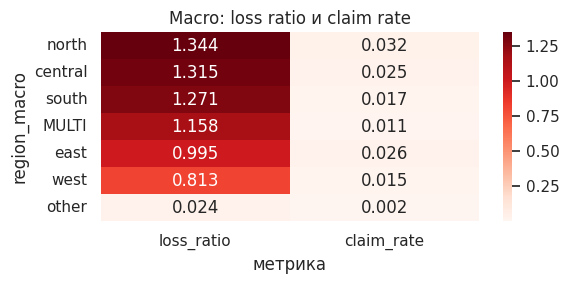

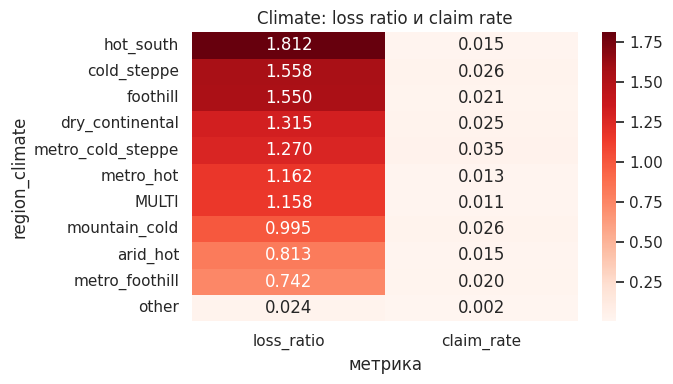

In [45]:
# Heatmap по loss ratio и claim rate

macro_heat = (
    macro_lr.rename("loss_ratio")
    .to_frame()
    .join(macro_stats["claim_rate"])
    .sort_values("loss_ratio", ascending=False)
)

plt.figure(figsize=(6, 3))
sns.heatmap(macro_heat, annot=True, fmt=".3f", cmap="Reds")
plt.title("Macro: loss ratio и claim rate")
plt.xlabel("метрика")
plt.ylabel("region_macro")
plt.tight_layout()
plt.show()

climate_heat = (
    climate_lr.rename("loss_ratio")
    .to_frame()
    .join(climate_stats["claim_rate"])
    .sort_values("loss_ratio", ascending=False)
)

plt.figure(figsize=(7, 4))
sns.heatmap(climate_heat, annot=True, fmt=".3f", cmap="Reds")
plt.title("Climate: loss ratio и claim rate")
plt.xlabel("метрика")
plt.ylabel("region_climate")
plt.tight_layout()
plt.show()


In [44]:
# Leakage-check: категории с 100% выплатами или 0% выплат при заметной численности
leakage_check = (
    df_contract.groupby([COL_ID, COL_NAME])["is_claim"]
    .agg(["mean", "count"])
    .sort_values("count", ascending=False)
)
suspicious = leakage_check[(leakage_check["mean"] == 1.0) | (leakage_check["mean"] == 0.0)]
display(suspicious.head(20))

print("Если есть категории с mean=1 или mean=0 и достаточным count, возможен leakage или артефакт сегментации.")

,,mean,count
region_id,region_name,,
18,Временная регистрация,0.0,300
22,20 Жетысуйская область,0.0,155
21,19 Абайская область,0.0,97


Если есть категории с mean=1 или mean=0 и достаточным count, возможен leakage или артефакт сегментации.


## Итоги

**Summary** — Региональные признаки дают измеримый, но умеренный сигнал; климатические зоны чуть сильнее макрорегионов, при этом общий loss ratio портфеля высокий ($\approx 1.23$), а worst-case зоны заметно хуже 70% таргета.

**Correlations** — Связь слабая: `is_claim` Pearson $-0.0154$, Spearman $-0.0135$; `claim_amount` Pearson $-0.0026$, Spearman $0.0045$ (на contract-level).

**Feature quality** — IV: `region_id` $\approx 0.1152$ (средний сигнал), `region_macro` $\approx 0.0775$ (слабый), `region_climate` $\approx 0.1028$ (слабый–средний). Leakage: possible для `other` и редких категорий из-за очень малых count.

**Engineering ideas** — Использовать `region_macro`/`region_climate` как устойчивые группировки; построить risk-tier по loss ratio; отдельно учитывать мегаполисы (`metro_*`) и северную зону с повышенной частотой.

**Caveats** — Loss ratio чувствителен к малым объемам премии (например, `other`); редкие категории могут искажать WoE/IV; макрогруппировки сглаживают сигнал по `region_id`.

**Next steps** — 1) Проверить устойчивость LR по зонам на сплите по времени/контрактам. 2) Посчитать доверительные интервалы LR для групп. 3) Сравнить gain в модели при замене `region_id` на `region_climate`.